# Investigation of random number generation methods and work engines

## F132357 - 19/03/2024

##### The following packages aid various parts of the following code. The 'matplotlib' is used to form the plots and graphs within the document. The 'numpy' package provides different mathematical functions available for use.

##### The 'random' package provides the inbuilt random number generators for use and finally 'scipy.integrate' provides a function to integrate a given function.

In [682]:
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.integrate import quad

### Part A: Random numbers and walks

##### For this part I look at how to simulate a random walks and random numbers. I then measure the randomness of the generated sets through various visual plots detailed below

#### **Question 1**

##### For my first alogrithm I chose the Linear Congruential method. I began by initializing 4 arrays 'r' for the set of random numbers, 'iSeq' for the sequence number, 'x' for the random numbers positioned at the even sequence numbers and 'y' for the random numbers positioned odd sequence numbers.

In [683]:
#r=[]; iSeq=[]; x=[]; y=[]; 

##### Here I initialise both the initial sequence number and the random number. In the Linear congruential method a seed number 'rstart' is required to initialise this generative method. The input values include a and c which are constants, 'M' is the Mod number and 'max' is the number of random numbers generated though the iterations.

In [684]:
#iCurrent=0.0; iSeq.append(iCurrent);
#rCurrent = rstart

##### These 'for' loops are used to iterate the random number (using the given formula) and then to iterate the sequence number. 

In [685]:
    #for i in range(1,max):
        #rCurrent=((a*rCurrent*M+c)%M)/M
        #r.append(rCurrent)
    
    #for i in range(1,(max-1)):
        #iCurrent = iCurrent + 1
        #iSeq.append(iCurrent)

##### Finally these sections forms the x and y arrays for the even sequence and odd sequence random number respectively. The if statement I added in for two scenarios, one is when the number of random numbers is even in which it left as is and the other is when the number of random numbers are odd in which case the even set in decreased by 1. This allows the ability to plot them against each other down the line irrespective on the input for 'max'.

In [686]:
#if len(r)%2 == 0:
#    x=[(r[i]) for i in range(len(r)) if i%2==0]
#    y=[(r[i]) for i in range(len(r)) if i%2!=0]
#else:
#    x=[(r[i]) for i in range(0, len(r) - 1) if i%2==0]
#    y=[(r[i]) for i in range(len(r)) if i%2!=0]
#return r,iSeq,x,y

In [687]:
#linear congruential method
def randomNum(a,c,M,max,rstart):
    r=[]; iSeq=[]; x=[]; y=[];
    #Sequence Number
    iCurrent=0.0; iSeq.append(iCurrent);
    rCurrent = rstart
    
    for i in range(1,max):
        rCurrent=((a*rCurrent*M+c)%M)/M
        r.append(rCurrent)
    
    for i in range(1,(max-1)):
        iCurrent = iCurrent + 1
        iSeq.append(iCurrent)
        
    #Plotting of successive number in a sequence  
    if len(r)%2 == 0:
        x=[(r[i]) for i in range(len(r)) if i%2==0]
        y=[(r[i]) for i in range(len(r)) if i%2!=0]
    else:
        x=[(r[i]) for i in range(0, len(r) - 1) if i%2==0]
        y=[(r[i]) for i in range(len(r)) if i%2!=0]
    return r,iSeq,x,y

##### Here I initialise the explained function above with some randomly chosen values, fulfilling the requirement of a minimum of 1000 values.

In [688]:
r1,i1,x1,y1=randomNum(57,10,7,1002,0.01)

##### Here I use a visual plot of the sequence number vs the random number to produce a visual plot that could show a potential pattern in the data. In this case there does not seem to be any clear correlation in the set of random number data.

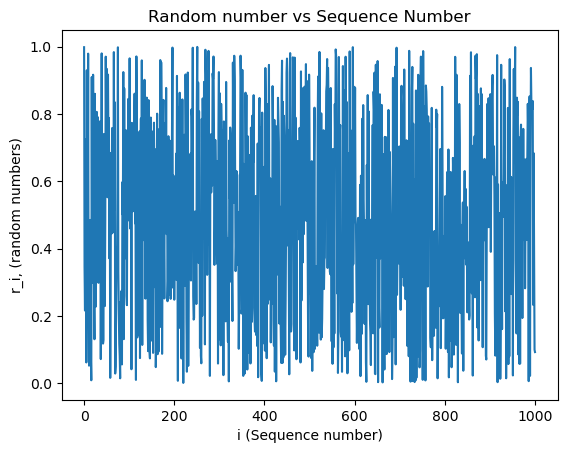

In [689]:
#Random number vs Sequence Number Check
plt.plot(i1,r1);
plt.xlabel("i (Sequence number)"); plt.ylabel("r_i, (random numbers)")
plt.title("Random number vs Sequence Number")
plt.show()

##### Here I plot the aforementioned sequential plot as my second visual plot to test randomness. As shown there is randomness in this given set with no clear patterns in the plot.

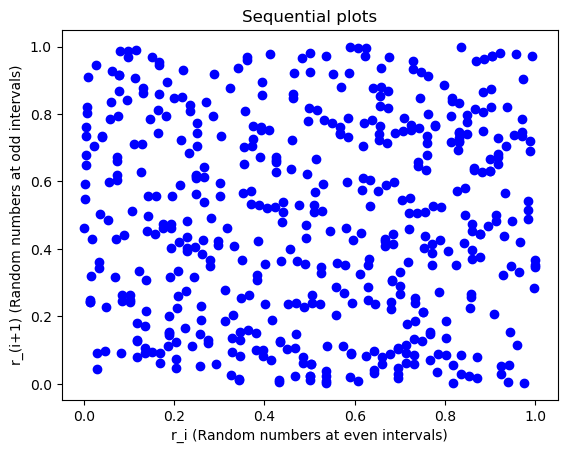

In [690]:
#Plotting of sequential plots
plt.plot(x1,y1,'bo')
plt.xlabel("r_i (Random numbers at even intervals)")
plt.ylabel("r_(i+1) (Random numbers at odd intervals)")
plt.title("Sequential plots")
plt.show()

##### My final choice for a visual plot is a histogram that shows the frequency of a range of number with regular intervals controlled by the bin number 'n_bin'. To create the historgram I simply used a native function (from matplotlib) to plot the histogram.

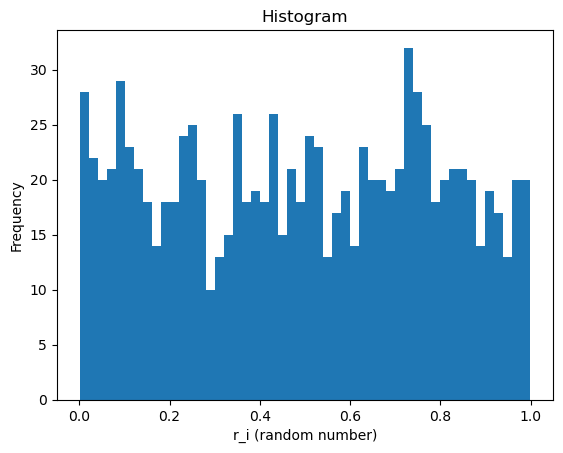

In [691]:
n_bin=50
plt.hist(r1,bins=n_bin); plt.ylabel("Frequency")
plt.xlabel("r_i (random number)"); plt.title("Histogram")
plt.show()

##### This following section is now for the inbuilt python function (another form of random number generation). This function is near identical with a few minor changes. The first change is the way I denoted the range of values using input values 'fro' and 'to'. As with the linear congruential method a seed number is required, denoted by the 'seed'.

##### This following equation uses a function 'random.random()' from the 'random' package that generates numbers from 0 to 1. Then by finding the difference between 'fro' and 'to' I obtain the value 'a' which upscales the range for the random numbers. Then add on 'fro' to shift the given range.

In [692]:
#rCurrent = a * (random.random()) + fro

In [693]:
def inbuilt(fro,to,N,seed):
    random.seed(seed)
    r=[]; iSeq=[]; x=[]; y=[];
    
    rCurrent=random.random(); r.append(rCurrent);
    #Sequence Number
    iCurrent=1.0; iSeq.append(iCurrent);
    a = to - fro
    for i in range(1,N):
        rCurrent = a * (random.random()) + fro
        r.append(rCurrent)
        iCurrent=iCurrent + 1.0
        iSeq.append(iCurrent)
        
    if len(r)%2 == 0:
        x=[(r[i]) for i in range(len(r)) if i%2==0]
        y=[(r[i]) for i in range(len(r)) if i%2!=0]
    else:
        x=[(r[i]) for i in range(0, len(r) - 1) if i%2==0]
        y=[(r[i]) for i in range(len(r)) if i%2!=0]
    return r,iSeq,x,y

r2,i2,x2,y2 = inbuilt(0,1,1000,5)

##### As done previously  I plot the random number vs the sequence number. Once again showing the randomness of the plot. Though it seems to be more random than that of the linear congruential method.

Text(0.5, 1.0, 'Random number vs Sequence number')

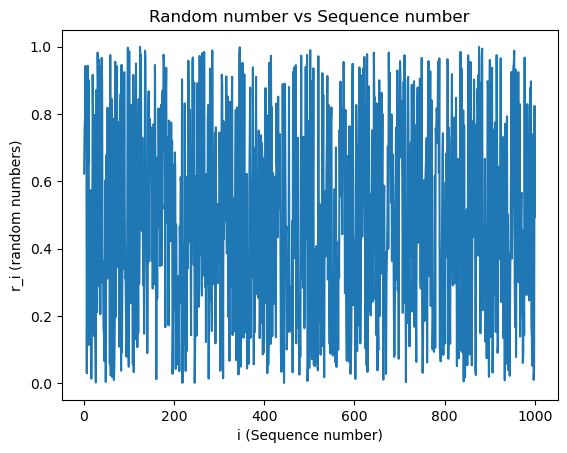

In [694]:
#Random number vs Sequence Number Check
plt.plot(i2,r2); plt.xlabel("i (Sequence number)")
plt.ylabel("r_i (random numbers)"); 
plt.title("Random number vs Sequence number")
#plt.show()

##### Looking at the sequential plot for the inbuilt random number generator it is clear that there is no pattern or correlation. Once again it seems to be a more random plot than when compared to the previous method.

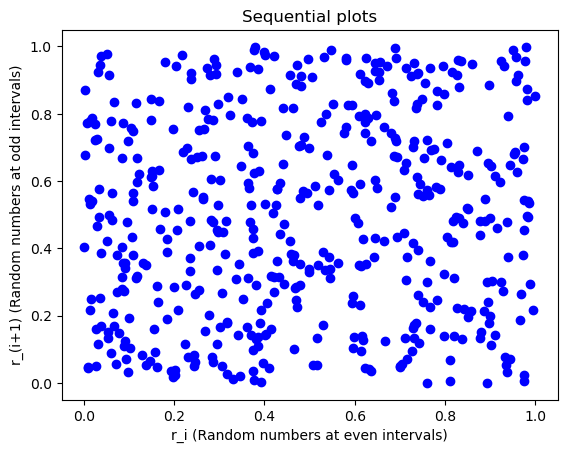

In [695]:
#Plotting of sequential plots
plt.plot(x2,y2, 'bo')
plt.xlabel("r_i (Random numbers at even intervals)")
plt.ylabel("r_(i+1) (Random numbers at odd intervals)")
plt.title("Sequential plots")
plt.show()

##### Now the final visual plot is the histogram that once again seems to shows a greater variation in the randomness of the released set of numbers.

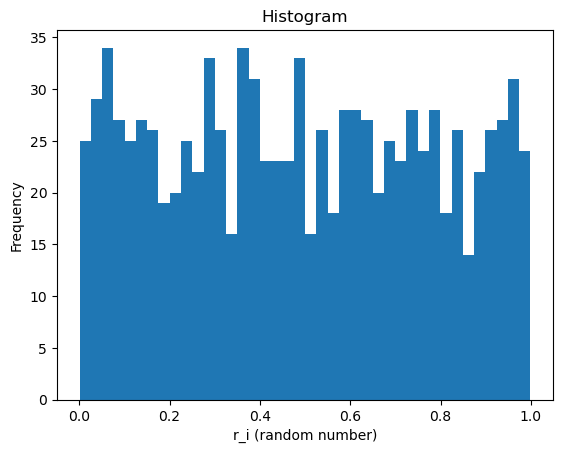

In [696]:
n_bin=40
plt.hist(r2,bins=n_bin); plt.ylabel("Frequency");
plt.xlabel("r_i (random number)"); plt.title("Histogram");
plt.show()

###### To conclude, based off of the visual plots, the inbuilt random number generator seems to be a more random generator as opposed to the linear congruential method. The 'random' module used the Mersenne Twister algorithm [3] to generate it's random numbers. This specifc algorithm has strong unpredictability, uniformity and independence. This strengthens it's randomness when compared to the linear congruential method

#### Question 2

##### Here I supplement the visual plot with some statistical tests to measure the randomness of the two generation methods. I look at two tests, the $k^{th}$ moment of the distribution and the nearest neighbour correlation.

##### In the function below it takes the random number set 'rnd', the 'k' and the number of iterations. The value of k controls what k_moment is a measure of. For example take $k=1$,  in that scenario it becomes a measure of the mean of the distribution whereas if $k=2$ then it is a measure of the variance.

In [697]:
def k_moment(k,max,rnd):
    xtot=0
    res=1/(k+1)
    for i in range(1,max+1):
        xtot+=(1/(max+1))*rnd[i]**k
    return xtot

k1 =k_moment(1,500,r1); k2 =k_moment(1,500,r2)
k3 =k_moment(2,500,r1); k4 =k_moment(2,500,r2)

##### When $k=1$ then mean of the inbuilt generator is closest to $0.5$ implying it highlights it has a more random set (As they range from 0 to 1). However when $k=2$, the linear congruential method has a greater variance than that of the inbuilt generator.

In [698]:
print("1st Kth moment (Linear congruential method) = ", k1) 
print("1st Kth moment (inbuilt generator) = ", k2)
print("2nd Kth moment (Linear congruential method) = ", k3) 
print("2nd Kth moment (inbuilt generator) = ", k4)

1st Kth moment (Linear congruential method) =  0.5080422436729402
1st Kth moment (inbuilt generator) =  0.4960884330411468
2nd Kth moment (Linear congruential method) =  0.3412258031001381
2nd Kth moment (inbuilt generator) =  0.3316691156666509


##### The nearest neighbour is a measure of the distance between two data points and correlated they are. If $k=1$ the  correlation will be considered only from the immediate neighbour of the specific data point. However if $k=2$ then you look at correlation between the specific data point and it's neighbour two positions away.

In [699]:
def nn_check(k,rnd,max):
    ntot=0
    for i in range(1,max+1-k):
        ntot+=(1/(max+1))*rnd[i]*rnd[i+k]
    return ntot

nn1=nn_check(1,r1,200); nn2=nn_check(1,r2,200)
nn3=nn_check(2,r1,200); nn4=nn_check(2,r2,200)

##### For both $k=1$ and $k=2$ the inbuilt generator is less clustered and has more distancing between it's data points. For this reason the nearest neighbour implies greater randomness in the inbuilt generator.

In [700]:
print("1st nearest neighbour (Linear congruential method) = ", nn1) 
print("1st nearest neighbour (inbuilt generator) = ", nn2)
print("2nd nearest neighbour (Linear congruential method) = ", nn3) 
print("2nd nearest neighbour (inbuilt generator) = ", nn4)

1st nearest neighbour (Linear congruential method) =  0.25096857903118924
1st nearest neighbour (inbuilt generator) =  0.28018723936618367
2nd nearest neighbour (Linear congruential method) =  0.24722075047531528
2nd nearest neighbour (inbuilt generator) =  0.2841577560574891


##### To conlude, considering all the evidence from the statistical tests, it's fair to deduce that the inbuilt generator is a better and more random algorithm. This follows on from the same conclusion being reached from the variation in the visual plots.

#### Question 3

##### For this question I use the inbuilt generator for the random walks. I start by initializing the arrays for the x and y to illustrate the walks in the xy plane. 'xc' and 'yc' act as the holding variables for the current values, before appending them to the initialized arrays.

In [701]:
def random_walk(Nstep):
    x=[]
    y=[]
    x.append(0)
    y.append(0)
    xc=0
    yc=0
    #generate numbers
    for i in range(1,Nstep+1):
        xc+=(random.random()-0.5)*2
        yc+=(random.random()-0.5)*2
        x.append(xc)
        y.append(yc)
    return x,y

##### Here I plot 3 individual random walks with steps of 20, 30 and 40 steps.

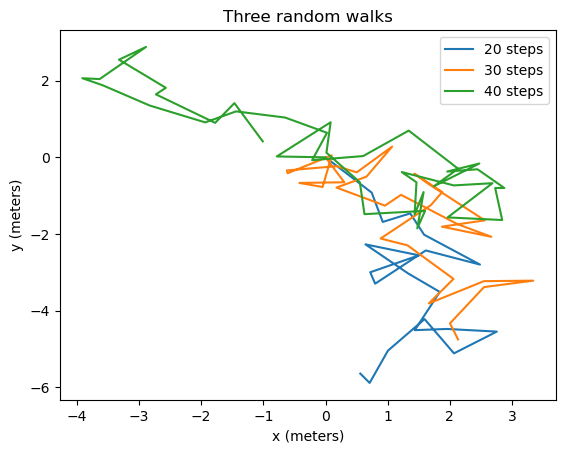

In [702]:
x1,y1=random_walk(20)
x2,y2=random_walk(30)
x3,y3=random_walk(40)
plt.plot(x1,y1, label = "20 steps")
plt.plot(x2,y2, label = "30 steps")
plt.plot(x3,y3, label = "40 steps")
plt.xlabel("x (meters)")
plt.ylabel("y (meters)")
plt.title("Three random walks")
plt.legend()

##### Below I calculate the walk distance for each random walk illustrate above. This function works by taking the first x and y values as well as the final x and y values of the random walks. Then by taking the differences between the corresponding x and y values then using pythagoras' theorem to find the direct distance from point a to point b.

In [703]:
def random_ave(xcor,ycor):
    Nf=len(xcor)-1
    dxi=xcor[0]; dxf=xcor[Nf]; dyi=ycor[0]; dyf=ycor[Nf];
    Rave = np.sqrt((dyf-dyi)**2 + (dxf-dxi)**2)
    return Rave, print('Walk distance =',Rave)

print('20 steps -'); Rdisp1 = random_ave(x1,y1)
print('30 steps -'); Rdisp2 = random_ave(x2,y2)
print('40 steps -'); Rdisp3 = random_ave(x3,y3)

20 steps -
Walk distance = 5.669887011076369
30 steps -
Walk distance = 5.207968733638605
40 steps -
Walk distance = 1.092118259672194


##### Here I reiterate the average walk only changing the output (making it solely '$R_{ave}$') for it's use in the following 'multiwalk' function.  

In [704]:
def random_ave1(xcor,ycor):
    Nf=len(xcor)-1
    dxi=xcor[0]; dxf=xcor[Nf]; dyi=ycor[0]; dyf=ycor[Nf];
    Rave = np.sqrt((dyf-dyi)**2 + (dxf-dxi)**2)
    return Rave

##### For this multiwalk function I use the previously defined functions to find the x and y arrays for the points across the x-y plane. Then in each iteration I use the x and y arrays to find the walk distance of each random walk. The walk distances are added together in the 'Rtot' variable. And this total is divided by the number of walks to find the average distance across those different walks. 

In [705]:
def multiwalk(Nwalk,Nstep):
    Rtot=0
    
    for i in range(1,Nwalk+1):
        xm,ym=random_walk(Nstep)
        Rtot+=random_ave1(xm,ym)
    return (Rtot/Nwalk)

##### Here I initialize the multiwalk function with the same number of walks with intervals of 2500, 3000, 3500 and 4000 steps. I plot the $R_{ave}$ vs $\sqrt(N_{step})$ to show the proportionality between the two values. This verifies the hypothesis through the approximate visual plot of an approximate linear graph.

Text(0, 0.5, 'sqrt(N_step)')

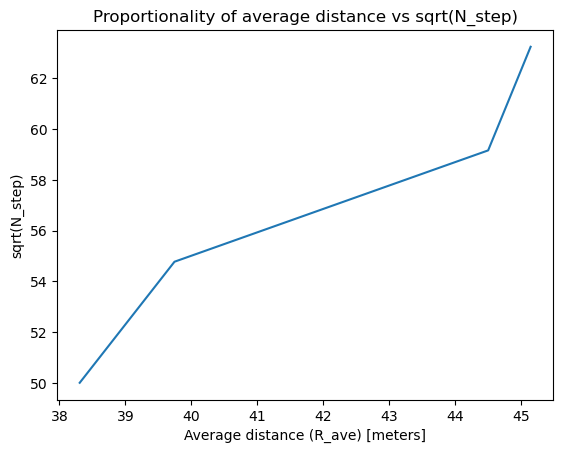

In [723]:
Nwalks = 200; Nstep0 = 2500; Nstep1 = 3000; Nstep2 = 3500; Nstep3 = 4000
Rave0 = multiwalk(Nwalks,Nstep0); Rave1 = multiwalk(Nwalks,Nstep1)
Rave2 = multiwalk(Nwalks,Nstep2); Rave3 = multiwalk(Nwalks,Nstep3)

Rave = [Rave0, Rave1, Rave2, Rave3]
sqrtNstep = [np.sqrt(Nstep0), np.sqrt(Nstep1), np.sqrt(Nstep2), np.sqrt(Nstep3)]

plt.plot(Rave, sqrtNstep)
plt.title("Proportionality of average distance vs sqrt(N_step)")
plt.xlabel("Average distance (R_ave) [meters]"); plt.ylabel("sqrt(N_step)")

### Part B: Heat engines

#### Question 1:

##### Here I create a function for an adiabatic expansion graph for a monotomic gas of $n = 1mol$. For the inputs of this function I have the initial temperature and the iterations input is used to dictate the breadth of the domain. I begin by initializing some commonly used constants, n, R, and gamma ($\frac{5}{3}$for an ideal gas). In the beginning snippet I initialize the initial volume as an arbitrary value of $100 m^3$.

##### In the code below I use the $PV = nRT$ (ideal gas equation) to find the initial pressure of the system. Following that I use the rule dictated by the adibatic nature of this system, $PV^\gamma = const$, to find the constant for this law.  

In [707]:
#initial_p = (n*R*initial_temp)/initial_volume
#const = initial_p * (initial_volume)**gamma

##### Hear I use the aforementioned rule and the calulated constant to find the pressure at each volume (that increases in regular intervals of 10). Following that, outside the 'for' loop I calculate the final temperature using the ideal gas equation and the final values for the pressure and the volume.

In [708]:
#for i in range(1, iterations):
    #volume.append(initial_volume)
    #initial_volume += 10
    #pressure.append(initial_p)
    #initial_p = const/(initial_volume**gamma)
#final_temperature = (initial_p * initial_volume)/(n*R)

##### The final section outputs the initial $(T_i)$ and the final $(T_f)$ temperatures. It then also plots all three adiabatic expansions at each temperature (200K, 300K and 400K). The graph follows the expected correlation in increasing temperatures as shown in the literature [1]. This confirms the accuracy of algorithm highlighted throughout the laid out function.

Initial temperature = 200 K
Final temperature = 61.25318201088778 K
Initial temperature = 300 K
Final temperature = 91.87977301633167 K
Initial temperature = 400 K
Final temperature = 122.50636402177555 K


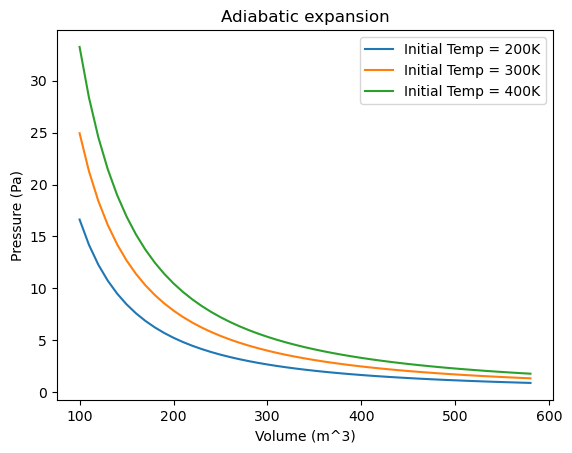

In [709]:
def adiabatic(initial_temp, iterations):
    n = 1; R = 8.314; gamma = 5/3;
    volume = []; pressure = [];
    initial_volume = 100.0; initial_p = (n*R*initial_temp)/initial_volume
    const = initial_p * (initial_volume)**gamma 
    
    for i in range(1, iterations):
        volume.append(initial_volume)
        initial_volume += 10
        pressure.append(initial_p)
        initial_p = const/(initial_volume**gamma)
        
    final_temperature = (initial_p * initial_volume)/(n*R)
    
    return volume, pressure, print('Initial temperature =', initial_temp, 'K'), print('Final temperature =', final_temperature, 'K')

v1, p1, Ti, Tf = adiabatic(200, 50)
v2, p2, Ti, Tf = adiabatic(300, 50)
v3, p3, Ti, Tf = adiabatic(400, 50)

plt.plot(v1,p1,label='Initial Temp = 200K')
plt.plot(v2,p2,label='Initial Temp = 300K') 
plt.plot(v3,p3,label='Initial Temp = 400K')
plt.xlabel('Volume (m^3)'); plt.ylabel('Pressure (Pa)');
plt.title('Adiabatic expansion'); plt.legend()

#### Question 2:

##### This isothermal expansion graph with multiple isothermal expansion branches. It is near identical to the adiabatic branch with the only difference being the updated pressure update equation with use of the ideal gas equation and the constant temperature.  (Shown below)

In [710]:
#initial_p = n*R*initial_temp/initial_volume

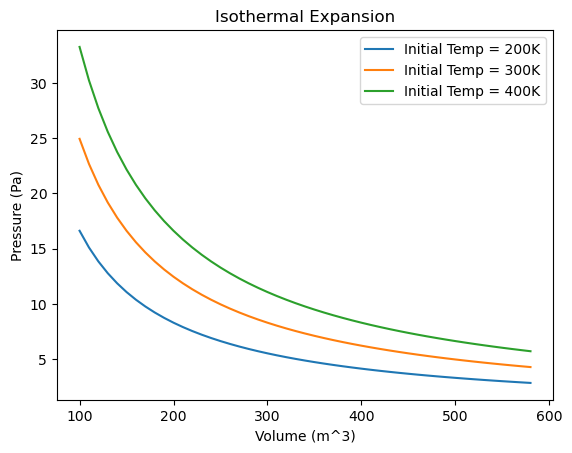

In [711]:
def isothermal(initial_temp, iterations):
    n = 1; R = 8.314; gamma = 5/3;
    volume = []; pressure = [];
    initial_volume = 100.0; initial_p = (n*R*initial_temp)/initial_volume
    const = initial_p * (initial_volume)**gamma 
    
    for i in range(1, iterations):
        volume.append(initial_volume)
        initial_volume += 10
        pressure.append(initial_p)
        initial_p = n*R*initial_temp/initial_volume
        
    return volume, pressure

v1, p1 = isothermal(200,50); v2, p2 = isothermal(300,50)
v3, p3 = isothermal(400,50)

plt.plot(v1,p1,label='Initial Temp = 200K')
plt.plot(v2,p2,label='Initial Temp = 300K') 
plt.plot(v3,p3,label='Initial Temp = 400K')
plt.xlabel('Volume (m^3)'); plt.ylabel('Pressure (Pa)');
plt.title('Isothermal Expansion'); plt.legend()

#### Question 3 & 4:

##### Here I construct a Carnot engine that combines previously used processes (i.e, isothermal expansion, adiabatic expansion etc.) For the input for this function, there is the temperature cold resvoir $(T_c)$ and the temperature at the hot reservoir $(T_h)$. I once again define the necessary constants and the different volume differentials for each process.

##### This following section focuses on the Isothermal expansion of the Carnot engine. For the isothermal expansion, $PV = nRT_h$ is rearranged for the pressure and is used to create a function for the volume (i.e. 'intergrand_1'). This is then used to intergrate the defined volumes, V1 and V2, using the 'quad' function from the intergration package. This intergration returns the change in the internal energy as a result of the isothermal expansion, denoted by 'Qiso1'.  The '_=' in the Qiso1 expression removes the error and returns the absolute value from the integral (a feature of the 'quad()' intergral function).

In [712]:
#Isothermal expansiom
#def intergrand_1(V):
    #return (n*R*Th)/V

#Change in the internal energy during the isothermal expansion
#Qiso1, _= quad(intergrand_1, V2, V1)

#V_iso_expan = np.arange(V1, V2, 1)
#P_iso_expan = (n*R*Th)/(V_iso_expan)

#a = len(P_iso_expan) - 1
#P2 = P_iso_expan[a]; const1 = P2*V2**gamma;

##### This following section is well document in Question 1. The main difference is the use of the 'intergrand_2' function to find the work done during the adiabatic expansion (Wadi1).

In [713]:
#Adiabatic expansiom
#def intergrand_2(V):
    #return const1/(V**gamma)

#V_adi_expan = np.arange(V2, V3, 1)
#P_adi_expan = (const1)/(V_adi_expan**gamma)

#Work done in the adiabatic expansion
#Wadi1, _= quad(intergrand_2, V3, V2)

##### This following snippet is for the isothermal compression branch. The only difference between the isothermal compression and expansion branches is both the new '$PV = nRT_c$' and the volume range.

In [714]:
#Isothermal compression
#def intergrand_3(V):
   # return (n*R*Tc)/V

#Change in the internal energy during the isothermal compression
#Qiso2, _= quad(intergrand_3,V3, V4)

#V_iso_compre = np.arange(V3,V4,-1)
#P_iso_compre = (n*R*Tc)/V_iso_compre

#b = len(P_iso_compre) - 1
#P4 = P_iso_compre[b]; const2 = P4*V4**gamma

##### This is repeated with the adiabatic compression branch in the same way. Following that, each branch is plotted onto the same graph. Using the change in internal energy from the isothermal branches, allowing me to calculate $\Delta Q$. Similarly, I also calculate the change in work done ($\Delta W$) from the adiabatic branches. Using 'Tc' and 'Th' I calculate the theoretical efficiency and compare this to the calculated efficiency using $\Delta W$ and $\Delta Q$.

In [715]:
#Change in internal energy
#delQ = Qiso1 - Qiso2

#Change in work done
#delW = Wadi1 - Wadi2

#Theoretical efficiency
#Eff_theo = 1 - (Tc/Th)

#Calculated efficiency
#Eff_actual = delW/delQ

In [716]:
def carnot(Tc,Th):
    n = 1.0; R = 8.314; gamma = 5/3;
    V1 = 25; V2 = 75; V3 = 135; V4 = 50;
    
    #Isothermal expansiom
    def intergrand_1(V):
        return (n*R*Th)/V
    
    #Change in the internal energy during the isothermal expansion
    Qiso1, _= quad(intergrand_1, V2, V1)
    
    V_iso_expan = np.arange(V1, V2, 1)
    P_iso_expan = (n*R*Th)/(V_iso_expan)
    
    a = len(P_iso_expan) - 1
    P2 = P_iso_expan[a]; const1 = P2*V2**gamma;
    
    #Adiabatic expansiom
    def intergrand_2(V):
        return const1/(V**gamma)
    
    V_adi_expan = np.arange(V2, V3, 1)
    P_adi_expan = (const1)/(V_adi_expan**gamma)
    
    #Work done in the adiabatic expansion
    Wadi1, _= quad(intergrand_2, V3, V2)
    
    #Isothermal compression
    def intergrand_3(V):
        return (n*R*Tc)/V
    
    #Change in the internal energy during the isothermal compression
    Qiso2, _= quad(intergrand_3,V3, V4)

    V_iso_compre = np.arange(V3,V4,-1)
    P_iso_compre = (n*R*Tc)/V_iso_compre
    
    b = len(P_iso_compre) - 1
    P4 = P_iso_compre[b]; const2 = P4*V4**gamma
    
    #Adiabatic Conpression
    def intergrand_4(V):
        return const2/(V**gamma)
    
    #Work done in the adiabatic compression
    Wadi2, _ = quad(intergrand_4,V4,V1)
    
    V_adi_compre = np.arange(V4,V1,-1)
    P_adi_compre = const2/(V_adi_compre**gamma)
    
    plt.plot(V_iso_expan, P_iso_expan, label = 'Isothermal expansion')
    plt.plot(V_adi_expan, P_adi_expan, label = 'Adiabatic expansion')
    plt.plot(V_iso_compre, P_iso_compre, label = 'Isothermal compression')
    plt.plot(V_adi_compre, P_adi_compre, label = 'Adiabatic compression')
    plt.xlabel('Volume (m^3)'); plt.ylabel('Pressure (Pa)');
    plt.title('Carnot engine'); plt.legend();
    plt.show()
    
    #Change in internal energy
    delQ = Qiso1 - Qiso2
    
    #Change in work done
    delW = Wadi1 - Wadi2
    
    #Theoretical efficiency
    Eff_theo = 1 - (Tc/Th)
    
    #Calculated efficiency
    Eff_actual = delW/delQ
    
    return print('delQ =',abs(delQ), 'J') , print('delW =',abs(delW), 'J'), print('Theoretical efficiency =',abs(Eff_theo)), print('Actual efficiency =',abs(Eff_actual))

##### Here I initialized the function with Tc = 200K and Th = 300K. The shape of the graph follows the expected shape of a Carnot engine [2]. The theoretical efficiency is a approx. 33% as opposed to the actual calculated efficiency of 19%. This discrepancy can be attributed to a carousel of assumptions. Here I assume that it acts as an ideal gas and that it is under quasi-steady-state conditions. Moreover, I assume that the input temperatures at each reservoir are constant.

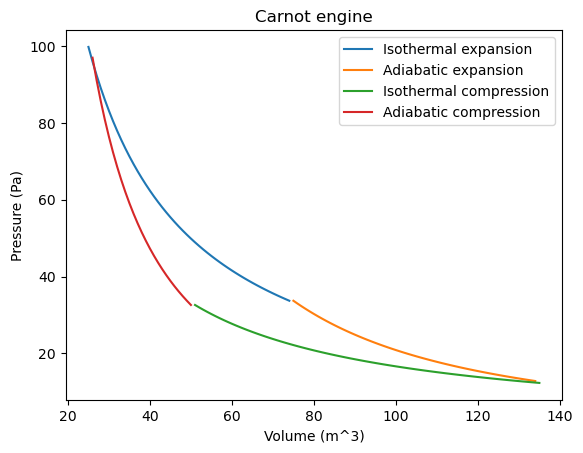

delQ = 1088.5797222345002 J
delW = 207.04877919901492 J
Theoretical efficiency = 0.33333333333333337
Actual efficiency = 0.19020084149097605


In [717]:
delQ, delW, Eff_theo, Eff_actual = carnot(200, 300)

### Part C : Extension - Ficticious engine cycle

##### Here I look at a function that simulates a ficticious engine cycle. There are two cycles to consider here, an adiabatic expansion and a linear compression. Here there a few input values given including, the initial pressure - $10^5$ Pa, initial volume - $24*10^{-3} m^3$, initial temperature  $293K$ and the final volume, $0.1 m^3$.

##### In this snippet, I look at the adiabatic expansion in which I initialize the volume and the pressure arrays. Using the initial volume and pressure I calculate the constant of proportionality. Using the initial values I calculate the change in temperature and use that to calculate the change in internal energy.

In [718]:
#Adiabatic expansion
#vadi = []; padi = [];
#const1 = Pi*Vi**gamma;

#Change in temperature
#Tf = Ti*(Vi/Vf)**(1-gamma)
#delT = Tf - Ti

#Change in internal energy
#delQ = Cm*delT

##### As done previously this calculates the change in the work done, $\Delta W$. Then using both $\Delta W$ and $\Delta Q$ I then calculate the efficiency, $\eta$.

In [719]:
#def intergrand(V):
        #return const1/(V**gamma)
    
#delW, _ = quad(intergrand, Vi, Vf)
#Eff = delW/delQ

##### Here, I find the volume values and their corresponding pressure values using a 'for' loop.

In [720]:
#Regular intervals for volume
#dV = (Vf - Vi)/iterations

#for i in range(1,iterations):
    #vadi.append(Vi)
    #Vi += dV
    #padi.append(Pi)
    #Pi = const1/(Vi**gamma)

In [721]:
#Ficticious engine cycle
def fictitious(Pi, Vi, Vf, Ti, iterations):
    n = 1; R = 8.314; gamma = 5/3; Cm=20.8; Pf=0.0;
    #Adiabatic expansion
    vadi = []; padi = [];
    const1 = Pi*Vi**gamma;
    
    def intergrand(V):
        return const1/(V**gamma)
    
    delW, _ = quad(intergrand, Vi, Vf)
    
    
    #Change in temperature
    Tf = Ti*(Vi/Vf)**(1-gamma)
    delT = Tf - Ti
    
    #Change in internal energy
    delQ = Cm*delT
    
    #Regular intervals for volume
    dV = (Vf - Vi)/iterations
    
    for i in range(1,iterations):
        vadi.append(Vi)
        Vi += dV
        padi.append(Pi)
        Pi = const1/(Vi**gamma)

    #Compression branch
    P0 = 128576; a=1190684; 
    Pi2 = P0-a*Vf; Pcompre = []; Vcompre = [];
    
    for i in range(1, iterations):
        Vcompre.append(Vf)
        Vf -= dV
        Pcompre.append(Pi2)
        Pi2 = P0 - a*Vf
    
    Eff = delW/delQ
    
    plt.plot(vadi,padi, label = 'Adiabatic expression')
    plt.plot(Vcompre,Pcompre, label = 'Compression branch')
    plt.title('Fictitious engine cycle'); plt.xlabel('Volume(m^3)'); plt.ylabel('Pressure (Pa)')
    plt.legend()
    plt.show()
    
    return print('Change in internal energy =', delQ, 'J'), print('Efficiency =', Eff)

##### Using the aforementioned input values I plot the engine cycle. The shape of the graph follows the expected outcome, as laid out in the assessment sheet. However the calculated efficiency is 23% as opposed to the 19% calculated with the Carnot engine. No engine with the same temperature differential should have a a greater efficiency than that of the Carnot engine. This could be a result of non-idealites in the gas as well as some potentially irreversible processes. 

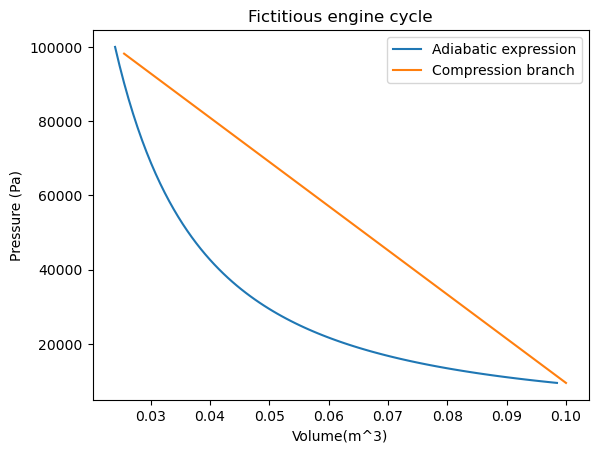

Change in internal energy = 9686.198153571 J
Efficiency = 0.22812823474535757


In [722]:
delQ = fictitious(10**5, 0.024, 0.1, 293, 100)    

## References

[1] - https://www.nuclear-power.com/nuclear-engineering/thermodynamics/thermodynamic-processes/adiabatic-process/adiabatic-curve-adiabat/

[2] - https://www.nuclear-power.com/nuclear-engineering/thermodynamics/thermodynamic-cycles/carnot-cycle-carnot-heat-engine/carnot-cycle-pv-ts-diagram/

[3] - https://en.wikipedia.org/wiki/Mersenne_Twister